# 정보 검색(Retrieval) 관련 EDA

다음 절차를 통해 Retrieval 난이도를 확인하면 좋음:

TF-IDF 기반 Top-1 retrieval을 해보고, 
실제 answer를 포함한 문서가 Top-K에 몇 % 포함되는지 확인


- Top-1 accuracy
- Top-5 accuracy
- Top-10 accuracy

질문과 정답 문서 간의 cosine similarity / TF-IDF 점수 분포


In [8]:
# 라이브러리 임포트
import sys
import os

# 프로젝트 루트를 path에 추가
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from datasets import load_from_disk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import AutoTokenizer

from src.retrieval.retrieval import SparseRetrieval

sns.set(style="whitegrid", font="NanumGothic", rc={"axes.unicode_minus": False})
plt.rcParams["figure.figsize"] = (12, 6)

print("라이브러리 임포트 완료")


라이브러리 임포트 완료


In [9]:
# 데이터 로드
print("데이터 로드 중...")
train_dataset = load_from_disk("../../data/train_dataset")

train_df = pd.DataFrame(train_dataset["train"])
val_df = pd.DataFrame(train_dataset["validation"])

print(f"Train 데이터: {len(train_df)}개")
print(f"Validation 데이터: {len(val_df)}개")
print(f"\n컬럼: {train_df.columns.tolist()}")


데이터 로드 중...
Train 데이터: 3952개
Validation 데이터: 240개

컬럼: ['title', 'context', 'question', 'id', 'answers', 'document_id', '__index_level_0__']


In [10]:
# Tokenizer 및 Retrieval 초기화
model_name = "klue/bert-base"  # 또는 사용할 모델
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)

# SparseRetrieval 초기화
retriever = SparseRetrieval(
    tokenize_fn=tokenizer.tokenize,
    data_path="../../data",
    context_path="wikipedia_documents.json"
)

print("Retriever 초기화 완료")


Lengths of unique contexts : 56737
Retriever 초기화 완료


In [ ]:
# Embedding 생성 (캐시된 파일이 있으면 로드, 없으면 생성)
print("Embedding 생성 중...")
retriever.get_sparse_embedding()
print(f"총 문서 개수: {len(retriever.contexts)}")
print("Exhaustive search를 사용합니다.")


Embedding 생성 중...
Embedding pickle load.
총 문서 개수: 56737

Exhaustive search만 사용합니다.


## Top-K Accuracy 계산


FAISS가 비활성화되어 있어 비교를 수행하지 않습니다.


In [ ]:
# Top-K retrieval 수행 및 정확도 계산
def calculate_topk_accuracy(df, retriever, topk_list=[1, 5, 10]):
    """
    Top-K retrieval accuracy를 계산합니다.
    original_context가 retrieved contexts의 Top-K에 포함되는지 확인합니다.
    """
    questions = df['question'].tolist()
    original_contexts = df['context'].tolist()
    
    # context를 contexts 리스트에서의 인덱스로 매핑
    context_to_idx = {ctx: idx for idx, ctx in enumerate(retriever.contexts)}
    
    # 각 질문에 대해 original_context의 인덱스 찾기
    original_indices = []
    for ctx in original_contexts:
        if ctx in context_to_idx:
            original_indices.append(context_to_idx[ctx])
        else:
            original_indices.append(-1)  # 찾을 수 없는 경우
    
    # Bulk retrieval 수행 (Top-10까지) - Exhaustive search 사용
    max_k = max(topk_list)
    doc_scores, doc_indices = retriever.get_relevant_doc_bulk(questions, k=max_k)
    
    # 각 Top-K에 대해 정확도 계산
    results = {}
    for k in topk_list:
        correct = 0
        for i, orig_idx in enumerate(original_indices):
            if orig_idx == -1:
                continue  # original context를 찾을 수 없는 경우 제외
            if orig_idx in doc_indices[i][:k]:
                correct += 1
        accuracy = correct / len([x for x in original_indices if x != -1])
        results[f'Top-{k}'] = accuracy
        print(f"Top-{k} Accuracy: {accuracy:.4f} ({correct}/{len([x for x in original_indices if x != -1])})")
    
    return results, doc_scores, doc_indices, original_indices

print("=" * 50)
print("Train 데이터 Retrieval Accuracy")
print("=" * 50)
train_results, train_scores, train_indices, train_orig_indices = calculate_topk_accuracy(
    train_df, retriever, topk_list=[1, 5, 10]
)

print("\n" + "=" * 50)
print("Validation 데이터 Retrieval Accuracy")
print("=" * 50)
val_results, val_scores, val_indices, val_orig_indices = calculate_topk_accuracy(
    val_df, retriever, topk_list=[1, 5, 10]
)


Train 데이터 Retrieval Accuracy (Exhaustive Search)
Top-1 Accuracy: 0.2503 (989/3952)
Top-5 Accuracy: 0.5349 (2114/3952)
Top-10 Accuracy: 0.6339 (2505/3952)

Validation 데이터 Retrieval Accuracy (Exhaustive Search)
Top-1 Accuracy: 0.2792 (67/240)
Top-5 Accuracy: 0.5833 (140/240)
Top-10 Accuracy: 0.6667 (160/240)


## 질문과 정답 문서 간의 Similarity 점수 분포


In [14]:
# 정답 문서의 similarity 점수 계산
def get_ground_truth_scores(df, retriever, doc_scores, doc_indices, original_indices):
    """
    각 질문에 대해 정답 문서의 similarity 점수를 추출합니다.
    """
    gt_scores = []
    gt_ranks = []
    
    for i, orig_idx in enumerate(original_indices):
        if orig_idx == -1:
            continue
        
        # 정답 문서가 retrieved documents 중 몇 번째에 있는지 확인
        if orig_idx in doc_indices[i]:
            rank = doc_indices[i].index(orig_idx) + 1
            score = doc_scores[i][rank - 1]
            gt_scores.append(score)
            gt_ranks.append(rank)
        else:
            # Top-K에 포함되지 않은 경우
            gt_scores.append(0.0)  # 또는 최소 점수
            gt_ranks.append(len(doc_indices[i]) + 1)
    
    return gt_scores, gt_ranks

train_gt_scores, train_gt_ranks = get_ground_truth_scores(
    train_df, retriever, train_scores, train_indices, train_orig_indices
)
val_gt_scores, val_gt_ranks = get_ground_truth_scores(
    val_df, retriever, val_scores, val_indices, val_orig_indices
)

print("=" * 50)
print("정답 문서 Similarity 점수 통계")
print("=" * 50)
print(f"\nTrain 데이터:")
print(f"  - 평균 점수: {np.mean(train_gt_scores):.4f}")
print(f"  - 중앙값 점수: {np.median(train_gt_scores):.4f}")
print(f"  - 최소 점수: {np.min(train_gt_scores):.4f}")
print(f"  - 최대 점수: {np.max(train_gt_scores):.4f}")
print(f"  - 표준편차: {np.std(train_gt_scores):.4f}")

print(f"\nValidation 데이터:")
print(f"  - 평균 점수: {np.mean(val_gt_scores):.4f}")
print(f"  - 중앙값 점수: {np.median(val_gt_scores):.4f}")
print(f"  - 최소 점수: {np.min(val_gt_scores):.4f}")
print(f"  - 최대 점수: {np.max(val_gt_scores):.4f}")
print(f"  - 표준편차: {np.std(val_gt_scores):.4f}")


정답 문서 Similarity 점수 통계

Train 데이터:
  - 평균 점수: 0.1637
  - 중앙값 점수: 0.1703
  - 최소 점수: 0.0000
  - 최대 점수: 0.7707
  - 표준편차: 0.1494

Validation 데이터:
  - 평균 점수: 0.1745
  - 중앙값 점수: 0.1670
  - 최소 점수: 0.0000
  - 최대 점수: 0.5945
  - 표준편차: 0.1518


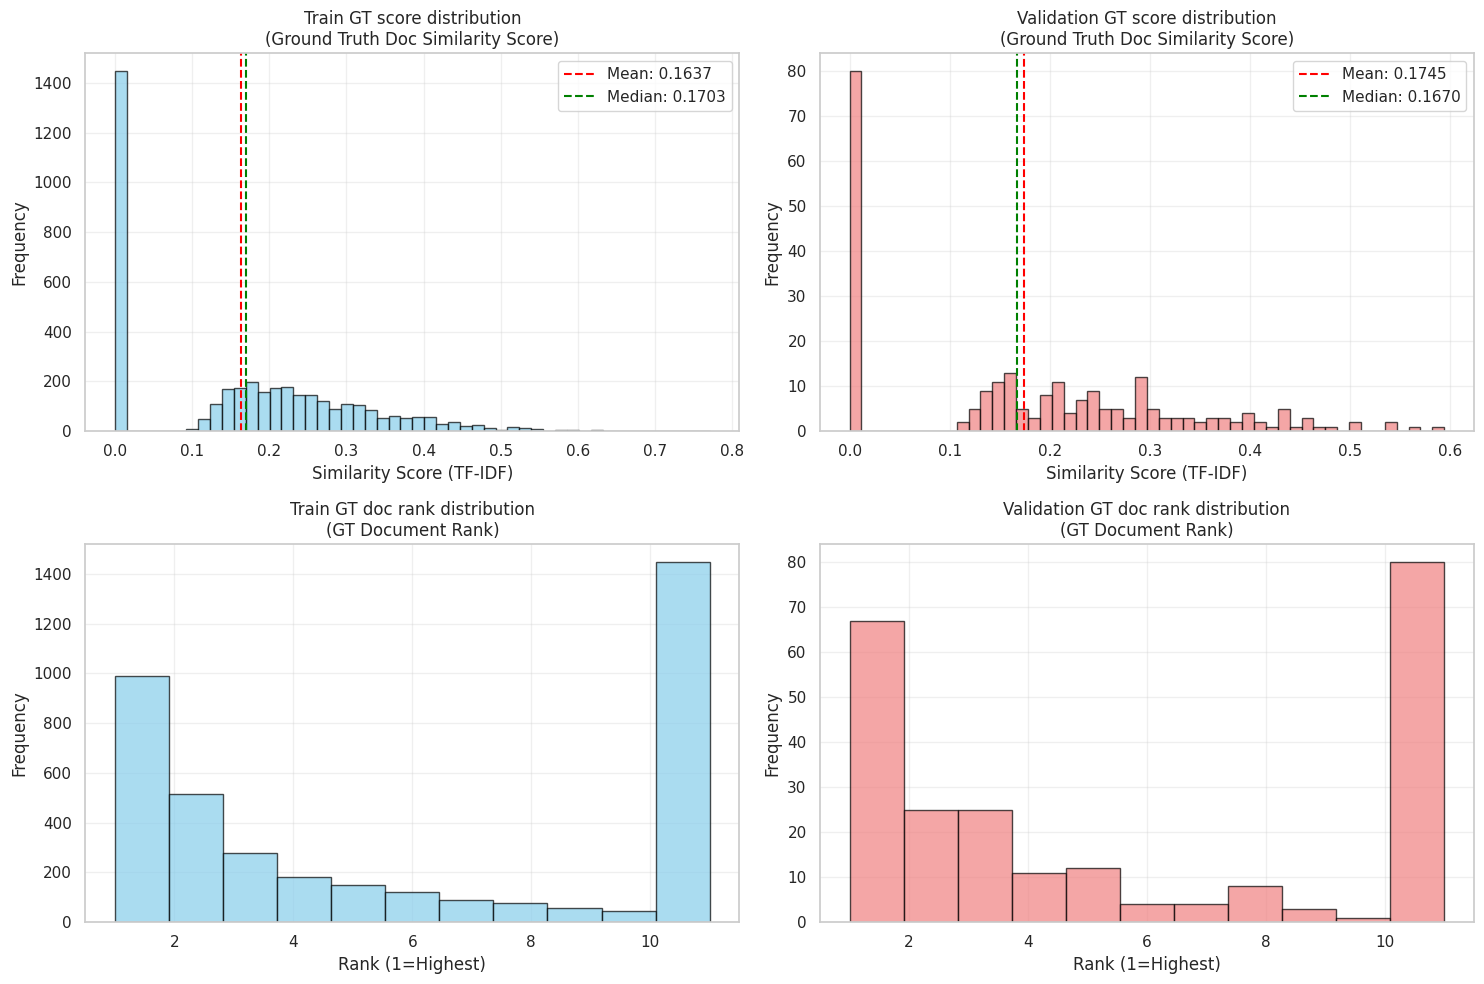

In [20]:
# Similarity 점수 분포 시각화 (한글 폰트 관련 Warning 및 네모박스 대체)
import matplotlib as mpl

# 기본 영문 폰트만 지정, 한글 텍스트는 모두 직접 영문으로 바꿔서 표기
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['axes.unicode_minus'] = False  # minus 표시 깨짐 방지

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Train GT score distribution (Similarity)
axes[0, 0].hist(train_gt_scores, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title("Train GT score distribution\n(Ground Truth Doc Similarity Score)", fontsize=12)
axes[0, 0].set_xlabel("Similarity Score (TF-IDF)")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].axvline(np.mean(train_gt_scores), color='red', linestyle='--', label=f"Mean: {np.mean(train_gt_scores):.4f}")
axes[0, 0].axvline(np.median(train_gt_scores), color='green', linestyle='--', label=f"Median: {np.median(train_gt_scores):.4f}")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Validation GT score distribution (Similarity)
axes[0, 1].hist(val_gt_scores, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0, 1].set_title("Validation GT score distribution\n(Ground Truth Doc Similarity Score)", fontsize=12)
axes[0, 1].set_xlabel("Similarity Score (TF-IDF)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].axvline(np.mean(val_gt_scores), color='red', linestyle='--', label=f"Mean: {np.mean(val_gt_scores):.4f}")
axes[0, 1].axvline(np.median(val_gt_scores), color='green', linestyle='--', label=f"Median: {np.median(val_gt_scores):.4f}")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Train GT document rank distribution
axes[1, 0].hist(train_gt_ranks, bins=min(20, max(train_gt_ranks)), alpha=0.7, color='skyblue', edgecolor='black')
axes[1, 0].set_title("Train GT doc rank distribution\n(GT Document Rank)", fontsize=12)
axes[1, 0].set_xlabel("Rank (1=Highest)")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Validation GT document rank distribution
axes[1, 1].hist(val_gt_ranks, bins=min(20, max(val_gt_ranks)), alpha=0.7, color='lightcoral', edgecolor='black')
axes[1, 1].set_title("Validation GT doc rank distribution\n(GT Document Rank)", fontsize=12)
axes[1, 1].set_xlabel("Rank (1=Highest)")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Top-1 score: Correct vs Incorrect

[Train data]
  - Top-1 correct mean score: 0.3020
  - Top-1 incorrect mean score: 0.1176

[Validation data]
  - Top-1 correct mean score: 0.3242
  - Top-1 incorrect mean score: 0.1166


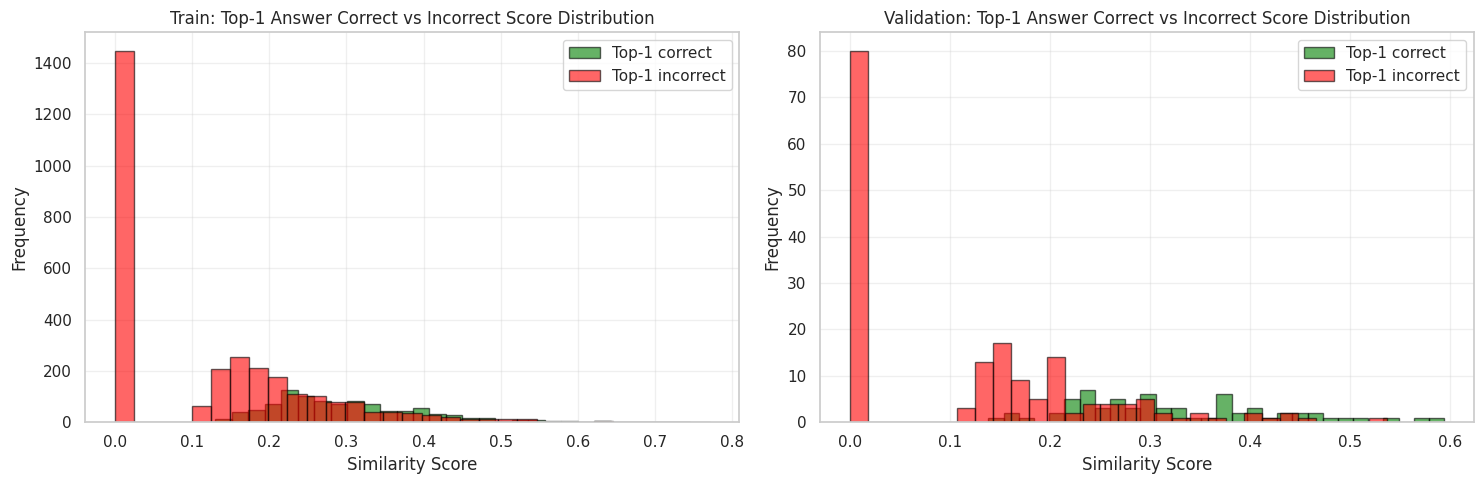

In [21]:
# Top-1 점수와 정답 문서 점수 비교 (네모 박스 한글 깨짐 방지: 모든 텍스트 영문 표기로 통일)
def get_top1_scores(doc_scores):
    """Extract Top-1 score for each question"""
    return [scores[0] if len(scores) > 0 else 0.0 for scores in doc_scores]

train_top1_scores = get_top1_scores(train_scores)
val_top1_scores = get_top1_scores(val_scores)

# Separate by GT document is Top-1 vs not Top-1
train_correct_top1 = [train_gt_scores[i] for i in range(len(train_gt_scores)) if train_gt_ranks[i] == 1]
train_incorrect_top1 = [train_gt_scores[i] for i in range(len(train_gt_scores)) if train_gt_ranks[i] > 1]
val_correct_top1 = [val_gt_scores[i] for i in range(len(val_gt_scores)) if val_gt_ranks[i] == 1]
val_incorrect_top1 = [val_gt_scores[i] for i in range(len(val_gt_scores)) if val_gt_ranks[i] > 1]

print("=" * 50)
print("Top-1 score: Correct vs Incorrect")
print("=" * 50)
print(f"\n[Train data]")
if len(train_correct_top1) > 0:
    print(f"  - Top-1 correct mean score: {np.mean(train_correct_top1):.4f}")
if len(train_incorrect_top1) > 0:
    print(f"  - Top-1 incorrect mean score: {np.mean(train_incorrect_top1):.4f}")

print(f"\n[Validation data]")
if len(val_correct_top1) > 0:
    print(f"  - Top-1 correct mean score: {np.mean(val_correct_top1):.4f}")
if len(val_incorrect_top1) > 0:
    print(f"  - Top-1 incorrect mean score: {np.mean(val_incorrect_top1):.4f}")

# Visualization with all axis+labels in English
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Train
if len(train_correct_top1) > 0 and len(train_incorrect_top1) > 0:
    axes[0].hist(train_correct_top1, bins=30, alpha=0.6, label='Top-1 correct', color='green', edgecolor='black')
    axes[0].hist(train_incorrect_top1, bins=30, alpha=0.6, label='Top-1 incorrect', color='red', edgecolor='black')
    axes[0].set_title('Train: Top-1 Answer Correct vs Incorrect Score Distribution', fontsize=12)
    axes[0].set_xlabel('Similarity Score')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Validation
if len(val_correct_top1) > 0 and len(val_incorrect_top1) > 0:
    axes[1].hist(val_correct_top1, bins=30, alpha=0.6, label='Top-1 correct', color='green', edgecolor='black')
    axes[1].hist(val_incorrect_top1, bins=30, alpha=0.6, label='Top-1 incorrect', color='red', edgecolor='black')
    axes[1].set_title('Validation: Top-1 Answer Correct vs Incorrect Score Distribution', fontsize=12)
    axes[1].set_xlabel('Similarity Score')
    axes[1].set_ylabel('Frequency')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 요약


In [ ]:
# 전체 요약
print("=" * 50)
print("Retrieval EDA 요약")
print("=" * 50)
print("사용된 방법: Exhaustive Search (TF-IDF)")

summary_data = {
    'Metric': ['Top-1 Accuracy', 'Top-5 Accuracy', 'Top-10 Accuracy', 
               '평균 Similarity 점수', '중앙값 Similarity 점수'],
    'Train': [
        f"{train_results['Top-1']:.4f}",
        f"{train_results['Top-5']:.4f}",
        f"{train_results['Top-10']:.4f}",
        f"{np.mean(train_gt_scores):.4f}",
        f"{np.median(train_gt_scores):.4f}"
    ],
    'Validation': [
        f"{val_results['Top-1']:.4f}",
        f"{val_results['Top-5']:.4f}",
        f"{val_results['Top-10']:.4f}",
        f"{np.mean(val_gt_scores):.4f}",
        f"{np.median(val_gt_scores):.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "=" * 50)
print("분석 결과")
print("=" * 50)
print(f"1. Top-1 Accuracy: Train {train_results['Top-1']:.2%}, Validation {val_results['Top-1']:.2%}")
print(f"2. Top-5 Accuracy: Train {train_results['Top-5']:.2%}, Validation {val_results['Top-5']:.2%}")
print(f"3. Top-10 Accuracy: Train {train_results['Top-10']:.2%}, Validation {val_results['Top-10']:.2%}")
print(f"\n4. 정답 문서의 평균 Similarity 점수:")
print(f"   - Train: {np.mean(train_gt_scores):.4f}")
print(f"   - Validation: {np.mean(val_gt_scores):.4f}")
print(f"\n5. Top-1에 정답이 포함된 비율:")
print(f"   - Train: {len(train_correct_top1)/len(train_gt_scores):.2%}")
print(f"   - Validation: {len(val_correct_top1)/len(val_gt_scores):.2%}")


Retrieval EDA 요약
사용된 방법: Exhaustive Search
           Metric  Train Validation
   Top-1 Accuracy 0.2503     0.2792
   Top-5 Accuracy 0.5349     0.5833
  Top-10 Accuracy 0.6339     0.6667
 평균 Similarity 점수 0.1637     0.1745
중앙값 Similarity 점수 0.1703     0.1670

분석 결과
1. Top-1 Accuracy: Train 25.03%, Validation 27.92%
2. Top-5 Accuracy: Train 53.49%, Validation 58.33%
3. Top-10 Accuracy: Train 63.39%, Validation 66.67%

4. 정답 문서의 평균 Similarity 점수:
   - Train: 0.1637
   - Validation: 0.1745

5. Top-1에 정답이 포함된 비율:
   - Train: 25.03%
   - Validation: 27.92%
